# Estudio de caso. Consulta en un Dataset

## Dataset Students Performance

**Nombre de los estudiantes:**  
José Eduardo Martínez Orrego  
Juan Felipe Rueda Orrego  

**Curso:** Fundamentos para IA  
**Actividad:** Estudio de caso  
**Docente:**  CESAR ALFONSO BOLADO SILVA
**Fecha de entrega:** 9 de julio de 2026  

## Objetivo general

Utilizar Python para leer, explorar y analizar un archivo CSV correspondiente al dataset Students Performance, identificando la estructura de sus variables, la calidad de los datos y posibles relaciones entre las columnas del conjunto de datos.

In [1]:
# ==========================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.set_option('display.max_columns', None)

print("Librerías cargadas correctamente.")
print("Carpeta actual:", os.getcwd())
print("Archivos en la carpeta:", os.listdir())

Librerías cargadas correctamente.
Carpeta actual: /content
Archivos en la carpeta: ['.config', 'sample_data']


In [2]:
# ==========================================
# 2. LECTURA DEL ARCHIVO CSV
# ==========================================

df = pd.read_csv("StudentsPerformance.csv")

print("Archivo cargado correctamente.")
df.head()

Archivo cargado correctamente.


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
# ==========================================
# 3. EXPLORACIÓN INICIAL DEL DATASET
# ==========================================

print("Tamaño del dataset:")
print(df.shape)

print("\nNombres de columnas:")
print(df.columns)

print("\nTipos de datos:")
print(df.dtypes)

print("\nInformación general:")
df.info()

Tamaño del dataset:
(1000, 8)

Nombres de columnas:
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

Tipos de datos:
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch    

In [4]:
# ==========================================
# 4. RESUMEN ESTADÍSTICO
# ==========================================

df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [5]:
# ==========================================
# 5. ÚLTIMAS FILAS DEL DATASET
# ==========================================

df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [6]:
# ==========================================
# 6. VALORES NULOS
# ==========================================

print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nTotal de valores nulos en el dataset:")
print(df.isnull().sum().sum())

Valores nulos por columna:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Total de valores nulos en el dataset:
0


In [7]:
# ==========================================
# 7. REGISTROS DUPLICADOS
# ==========================================

duplicados = df.duplicated().sum()

print("Número de registros duplicados:", duplicados)

Número de registros duplicados: 0


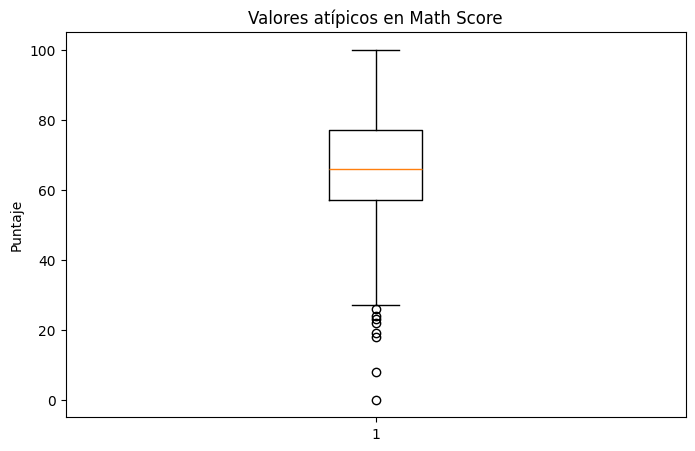

In [8]:
# ==========================================
# 8. VALORES ATÍPICOS - MATH SCORE
# ==========================================

plt.figure(figsize=(8,5))
plt.boxplot(df["math score"])
plt.title("Valores atípicos en Math Score")
plt.ylabel("Puntaje")
plt.show()

In [9]:
# ==========================================
# 9. DETECCIÓN DE VALORES ATÍPICOS CON IQR
# ==========================================

Q1 = df["math score"].quantile(0.25)
Q3 = df["math score"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

atipicos_math = df[
    (df["math score"] < limite_inferior) |
    (df["math score"] > limite_superior)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)
print("Cantidad de valores atípicos en math score:", len(atipicos_math))

atipicos_math

Q1: 57.0
Q3: 77.0
IQR: 20.0
Límite inferior: 27.0
Límite superior: 107.0
Cantidad de valores atípicos en math score: 8


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
17,female,group B,some high school,free/reduced,none,18,32,28
59,female,group C,some high school,free/reduced,none,0,17,10
145,female,group C,some college,free/reduced,none,22,39,33
338,female,group B,some high school,free/reduced,none,24,38,27
466,female,group D,associate's degree,free/reduced,none,26,31,38
787,female,group B,some college,standard,none,19,38,32
842,female,group B,high school,free/reduced,completed,23,44,36
980,female,group B,high school,free/reduced,none,8,24,23


In [10]:
# ==========================================
# 10. ANÁLISIS CATEGÓRICO - GENDER Y LUNCH
# ==========================================

print("Variable categórica: gender")
print("\nFrecuencias:")
print(df["gender"].value_counts())

print("\nPorcentajes:")
print(df["gender"].value_counts(normalize=True) * 100)

print("\n------------------------------------")

print("Variable categórica: lunch")
print("\nFrecuencias:")
print(df["lunch"].value_counts())

print("\nPorcentajes:")
print(df["lunch"].value_counts(normalize=True) * 100)

Variable categórica: gender

Frecuencias:
gender
female    518
male      482
Name: count, dtype: int64

Porcentajes:
gender
female    51.8
male      48.2
Name: proportion, dtype: float64

------------------------------------
Variable categórica: lunch

Frecuencias:
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

Porcentajes:
lunch
standard        64.5
free/reduced    35.5
Name: proportion, dtype: float64


In [11]:
# ==========================================
# 11. ANÁLISIS CATEGÓRICO - TEST PREPARATION COURSE
# ==========================================

print("Variable categórica: test preparation course")

print("\nFrecuencias:")
print(df["test preparation course"].value_counts())

print("\nPorcentajes:")
print(df["test preparation course"].value_counts(normalize=True) * 100)

Variable categórica: test preparation course

Frecuencias:
test preparation course
none         642
completed    358
Name: count, dtype: int64

Porcentajes:
test preparation course
none         64.2
completed    35.8
Name: proportion, dtype: float64


In [ ]:
# ==========================================
# 12. ANÁLISIS NUMÉRICO - MATH SCORE Y READING SCORE
# ==========================================

print("Math Score:")
print(df["math score"].describe())

print("\nReading Score:")
print(df["reading score"].describe())

In [ ]:
# ==========================================
# 13. ANÁLISIS NUMÉRICO - WRITING SCORE
# ==========================================

print("Writing Score:")
print(df["writing score"].describe())

In [ ]:
# ==========================================
# 14. RELACIÓN ENTRE CURSO DE PREPARACIÓN Y NOTAS
# ==========================================

df.groupby("test preparation course")[["math score", "reading score", "writing score"]].mean()

In [12]:
# ==========================================
# 15. RELACIÓN ENTRE TIPO DE ALMUERZO Y NOTAS
# ==========================================

df.groupby("lunch")[["math score", "reading score", "writing score"]].mean()

,math score,reading score,writing score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


In [13]:
# ==========================================
# 16. CORRELACIÓN ENTRE VARIABLES NUMÉRICAS
# ==========================================

df[["math score", "reading score", "writing score"]].corr()

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000
